In [9]:
!pip install pandas matplotlib seaborn wordcloud

In [10]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [12]:
import pandas as pd

try:
    df = pd.read_csv("spam.csv", encoding='latin-1')
    if 'v1' in df.columns:
        df = df[['v1','v2']]
        df.columns = ['label','message']
except:
    df = pd.read_csv("SMSSpamCollection", sep='\t', names=['label','message'])

print(df.head())
print(df.columns)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='object')


In [13]:
print("Shape:", df.shape)
print("\nSpam vs Ham count:\n", df['label'].value_counts())
print("\nMissing values:\n", df.isnull().sum())

Shape: (5572, 2)

Spam vs Ham count:
 label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
 label      0
message    0
dtype: int64


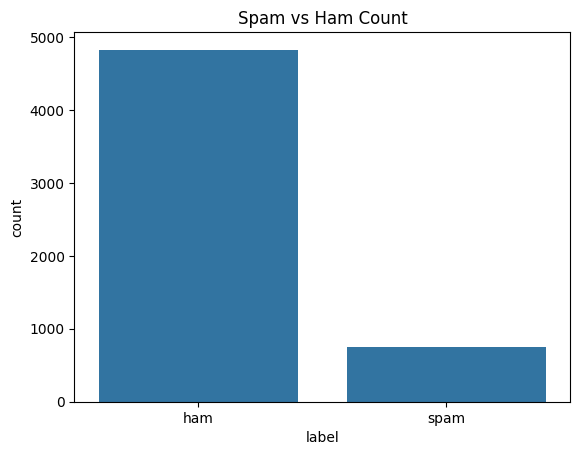

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Count")
plt.show()

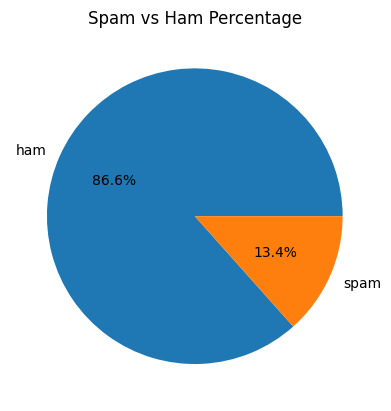

In [15]:
df['label'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Spam vs Ham Percentage")
plt.ylabel('')
plt.show()

In [19]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

df['clean_message'] = df['message'].apply(clean_text)

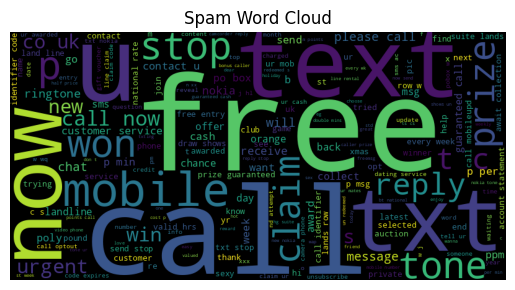

In [20]:
from wordcloud import WordCloud

spam_words = " ".join(df[df['label']=='spam']['clean_message'])

wordcloud = WordCloud(width=800, height=400).generate(spam_words)

plt.imshow(wordcloud)
plt.axis('off')
plt.title("Spam Word Cloud")
plt.show()

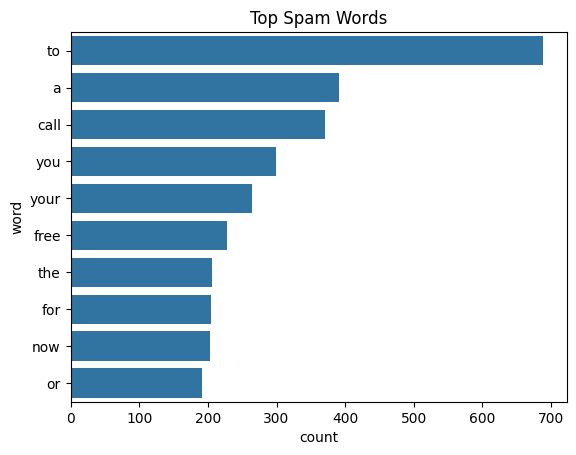

In [21]:
from collections import Counter

words = spam_words.split()
common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(common_words, columns=['word','count'])

sns.barplot(x='count', y='word', data=words_df)
plt.title("Top Spam Words")
plt.show()

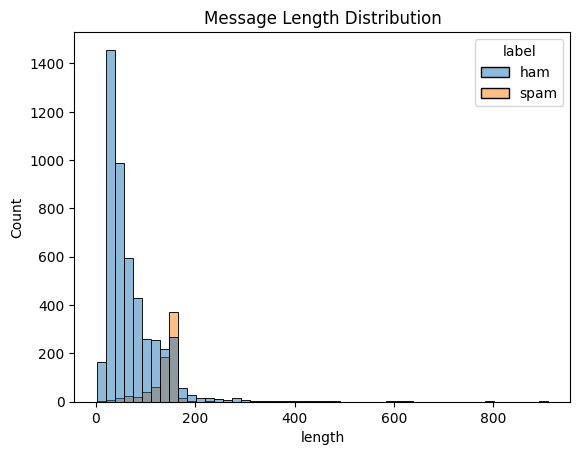

In [22]:
df['length'] = df['message'].apply(len)

sns.histplot(data=df, x='length', hue='label', bins=50)
plt.title("Message Length Distribution")
plt.show()